In [21]:
import pandas as pd
import glob
import os

# SOURCE: where your raw downloaded files are
source_folder = "../Data/2024"

# TARGET: where you want consolidated output
target_folder = "../Data"

os.makedirs(target_folder, exist_ok=True)

print("Source folder :", source_folder)
print("Target folder :", target_folder)

Source folder : /Users/nathdwar/Downloads/2024
Target folder : /Users/nathdwar/Python/Algo Trading/history data


In [24]:
def parse_date_token(token):
    return pd.to_datetime(token, format="%d%b%y", errors="coerce")


def parse_filename_dates(filepath):
    """
    Expected format:
    NIFTY-31OCT24-30SEP24.csv

    => expiry = 31OCT24
    => trade_date = 30SEP24
    """
    fname = os.path.basename(filepath).replace(".csv", "").upper()
    parts = fname.split("-")

    if len(parts) < 3:
        return pd.NaT, pd.NaT

    expiry_token = parts[1].strip()
    trade_token = parts[2].strip()

    expiry_dt = parse_date_token(expiry_token)
    trade_dt = parse_date_token(trade_token)

    return expiry_dt, trade_dt


def load_single_option_file(filepath):
    df = pd.read_csv(filepath)
    df.columns = [c.lower().strip() for c in df.columns]

    rename_map = {
        "strike_price": "strike",
        "right": "option_type",
        "open_interest": "oi"
    }
    df = df.rename(columns=rename_map)

    expiry_dt, trade_dt = parse_filename_dates(filepath)

    if pd.isna(expiry_dt) or pd.isna(trade_dt):
        raise ValueError(f"Could not parse expiry/trade date from filename: {filepath}")

    # original datetime column contains only time like 09:15
    df["datetime"] = pd.to_datetime(
        trade_dt.strftime("%Y-%m-%d") + " " + df["datetime"].astype(str),
        errors="coerce"
    )

    df["expiry"] = pd.Timestamp(expiry_dt).normalize() + pd.Timedelta(hours=15, minutes=30)
    df["symbol"] = "NIFTY"

    df["strike"] = pd.to_numeric(df["strike"], errors="coerce")
    df["option_type"] = df["option_type"].astype(str).str.upper().str.strip()

    needed = ["datetime", "expiry", "symbol", "strike", "option_type", "open", "high", "low", "close", "oi", "volume"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {os.path.basename(filepath)}: {missing}")

    df = df.dropna(subset=["datetime", "strike", "option_type", "close"]).copy()

    return df[["datetime", "expiry", "symbol", "strike", "option_type", "open", "high", "low", "close", "oi", "volume"]]

In [26]:
files = glob.glob(os.path.join(source_folder, "**", "*.csv"), recursive=True)

print("Total CSV files found:", len(files))
print("Sample files:", [os.path.basename(x) for x in files[:5]])

Total CSV files found: 1415
Sample files: ['expiry.csv', 'NIFTY-02JAN25-06DEC24.csv', 'NIFTY-26DEC24-05DEC24.csv', 'NIFTY-26DEC24-04DEC24.csv', 'NIFTY-09JAN25-06DEC24.csv']


In [28]:
all_parts = []
bad_files = []

for i, f in enumerate(files, 1):
    try:
        temp = load_single_option_file(f)
        all_parts.append(temp)

        if i % 100 == 0:
            print(f"Loaded {i} files")

    except Exception as e:
        bad_files.append((f, str(e)))

print("Good files:", len(all_parts))
print("Bad files :", len(bad_files))

Loaded 100 files
Loaded 200 files
Loaded 300 files
Loaded 400 files
Loaded 500 files
Loaded 700 files
Loaded 800 files
Loaded 900 files
Loaded 1000 files
Loaded 1100 files
Loaded 1200 files
Loaded 1300 files
Loaded 1400 files
Good files: 1402
Bad files : 13


In [29]:
options_df = pd.concat(all_parts, ignore_index=True)

options_df = options_df.sort_values(
    ["datetime", "expiry", "strike", "option_type"]
).reset_index(drop=True)

print("Final rows:", len(options_df))
display(options_df.head(10))

Final rows: 55487070


,datetime,expiry,symbol,strike,option_type,open,high,low,close,oi,volume
0,2024-01-01 09:15:00,2024-01-04 15:30:00,NIFTY,18500,PE,0.95,1.20,0.95,1.00,464300,13200
1,2024-01-01 09:15:00,2024-01-04 15:30:00,NIFTY,18700,PE,1.30,1.30,1.15,1.15,39900,450
2,2024-01-01 09:15:00,2024-01-04 15:30:00,NIFTY,19000,PE,0.90,1.35,0.90,1.15,1531500,38350
3,2024-01-01 09:15:00,2024-01-04 15:30:00,NIFTY,19200,PE,1.45,1.45,1.45,1.45,61000,50
4,2024-01-01 09:15:00,2024-01-04 15:30:00,NIFTY,19250,PE,1.45,1.45,1.35,1.35,19600,550
5,2024-01-01 09:15:00,2024-01-04 15:30:00,NIFTY,19300,PE,0.85,1.50,0.85,1.50,42300,900
6,2024-01-01 09:15:00,2024-01-04 15:30:00,NIFTY,19350,PE,1.50,1.50,1.50,1.50,15800,100
7,2024-01-01 09:15:00,2024-01-04 15:30:00,NIFTY,19400,PE,1.25,1.65,1.25,1.30,159200,2550
8,2024-01-01 09:15:00,2024-01-04 15:30:00,NIFTY,19450,PE,1.40,1.55,1.40,1.55,27400,800
9,2024-01-01 09:15:00,2024-01-04 15:30:00,NIFTY,19500,PE,0.90,1.90,0.90,1.25,1290750,20500


In [30]:
print("Unique expiries:", options_df["expiry"].nunique())
print(options_df["expiry"].drop_duplicates().sort_values().head(20))
print(options_df["expiry"].drop_duplicates().sort_values().tail(20))

Unique expiries: 60
0          2024-01-04 15:30:00
110        2024-01-11 15:30:00
188        2024-01-18 15:30:00
208        2024-01-25 15:30:00
280        2024-02-01 15:30:00
931493     2024-02-08 15:30:00
2265345    2024-02-15 15:30:00
3408571    2024-02-22 15:30:00
4149190    2024-02-29 15:30:00
5134292    2024-03-07 15:30:00
6459846    2024-03-14 15:30:00
7707768    2024-03-21 15:30:00
282        2024-03-28 15:30:00
10033042   2024-04-04 15:30:00
11059270   2024-04-10 15:30:00
12364411   2024-04-18 15:30:00
12758532   2024-04-25 15:30:00
13654997   2024-05-02 15:30:00
14807661   2024-05-09 15:30:00
15498674   2024-05-16 15:30:00
Name: expiry, dtype: datetime64[ns]
38187599   2024-10-10 15:30:00
39317921   2024-10-17 15:30:00
40288605   2024-10-24 15:30:00
41222986   2024-10-31 15:30:00
42238779   2024-11-07 15:30:00
43415200   2024-11-14 15:30:00
44578844   2024-11-21 15:30:00
45683329   2024-11-28 15:30:00
46963957   2024-12-05 15:30:00
47987859   2024-12-12 15:30:00
49056824   202

In [31]:
print("Unique expiries:", options_df["expiry"].nunique())
print(options_df["expiry"].drop_duplicates().sort_values().head(20))
print(options_df["expiry"].drop_duplicates().sort_values().tail(20))

Unique expiries: 60
0          2024-01-04 15:30:00
110        2024-01-11 15:30:00
188        2024-01-18 15:30:00
208        2024-01-25 15:30:00
280        2024-02-01 15:30:00
931493     2024-02-08 15:30:00
2265345    2024-02-15 15:30:00
3408571    2024-02-22 15:30:00
4149190    2024-02-29 15:30:00
5134292    2024-03-07 15:30:00
6459846    2024-03-14 15:30:00
7707768    2024-03-21 15:30:00
282        2024-03-28 15:30:00
10033042   2024-04-04 15:30:00
11059270   2024-04-10 15:30:00
12364411   2024-04-18 15:30:00
12758532   2024-04-25 15:30:00
13654997   2024-05-02 15:30:00
14807661   2024-05-09 15:30:00
15498674   2024-05-16 15:30:00
Name: expiry, dtype: datetime64[ns]
38187599   2024-10-10 15:30:00
39317921   2024-10-17 15:30:00
40288605   2024-10-24 15:30:00
41222986   2024-10-31 15:30:00
42238779   2024-11-07 15:30:00
43415200   2024-11-14 15:30:00
44578844   2024-11-21 15:30:00
45683329   2024-11-28 15:30:00
46963957   2024-12-05 15:30:00
47987859   2024-12-12 15:30:00
49056824   202

In [32]:
parquet_path = os.path.join(target_folder, "NIFTY_OPTIONS_2024_CONSOLIDATED.parquet")

options_df.to_parquet(parquet_path, index=False)

print("Saved parquet:", parquet_path)

Saved parquet: /Users/nathdwar/Python/Algo Trading/history data/NIFTY_OPTIONS_2024_CONSOLIDATED.parquet


In [33]:
import pandas as pd

options_file = "./Data/NIFTY_OPTIONS_2024_CONSOLIDATED.parquet"

options_df = pd.read_parquet(options_file)

print("Options rows:", len(options_df))
print(options_df.columns.tolist())

options_df.head()

Options rows: 55487070
['datetime', 'expiry', 'symbol', 'strike', 'option_type', 'open', 'high', 'low', 'close', 'oi', 'volume']


,datetime,expiry,symbol,strike,option_type,open,high,low,close,oi,volume
0,2024-01-01 09:15:00,2024-01-04 15:30:00,NIFTY,18500,PE,0.95,1.20,0.95,1.00,464300,13200
1,2024-01-01 09:15:00,2024-01-04 15:30:00,NIFTY,18700,PE,1.30,1.30,1.15,1.15,39900,450
2,2024-01-01 09:15:00,2024-01-04 15:30:00,NIFTY,19000,PE,0.90,1.35,0.90,1.15,1531500,38350
3,2024-01-01 09:15:00,2024-01-04 15:30:00,NIFTY,19200,PE,1.45,1.45,1.45,1.45,61000,50
4,2024-01-01 09:15:00,2024-01-04 15:30:00,NIFTY,19250,PE,1.45,1.45,1.35,1.35,19600,550


In [34]:
print("Creating fast option lookup dictionary...")

option_groups = {
    key: grp.sort_values("datetime").reset_index(drop=True)
    for key, grp in options_df.groupby(["expiry", "strike", "option_type"])
}

available_expiries = sorted(options_df["expiry"].dropna().unique())

print("Total contracts:", len(option_groups))
print("Total expiries:", len(available_expiries))

Creating fast option lookup dictionary...
Total contracts: 10579
Total expiries: 60


In [35]:
#Cell 10 — Helper functions

In [36]:
def get_next_expiry(current_time):
    for exp in available_expiries:
        if exp > current_time:
            return exp
    return None


def get_option_price(expiry, strike, option_type, time):
    key = (expiry, strike, option_type)

    if key not in option_groups:
        return None

    df = option_groups[key]

    rows = df[df["datetime"] >= time]

    if rows.empty:
        return None

    return rows.iloc[0]["close"]

In [37]:
#Cell 11 — Survivor Strategy Backtest Engine. This Implements Strategy Logic

In [38]:
class SurvivorManagedBacktest:

    def __init__(self, spot_df, config, risk_config):
        self.spot = spot_df.copy()
        self.config = config
        self.risk_config = risk_config

        self.pe_gap = config["pe_gap"]
        self.ce_gap = config["ce_gap"]
        self.pe_symbol_gap = config["pe_symbol_gap"]
        self.ce_symbol_gap = config["ce_symbol_gap"]
        self.pe_quantity = config["pe_quantity"]
        self.ce_quantity = config["ce_quantity"]
        self.pe_reset_gap = config["pe_reset_gap"]
        self.ce_reset_gap = config["ce_reset_gap"]
        self.sell_multiplier_threshold = config["sell_multiplier_threshold"]
        self.min_price_to_sell = config["min_price_to_sell"]

        self.pe_last = None
        self.ce_last = None
        self.pe_reset_gap_flag = 0
        self.ce_reset_gap_flag = 0

        self.open_positions = []
        self.closed_trades = []
        self.skipped = []

        self.strike_step = 50

    def current_open_count(self, current_time):
        return sum(
            1 for pos in self.open_positions
            if pos["status"] == "OPEN" and pos["entry_time"] <= current_time < pos["exit_time"]
        )

    def choose_next_expiry(self, current_time):
        for exp in available_expiries:
            if exp > current_time:
                return exp
        return None

    def find_contract_and_entry(self, current_time, spot_price, option_type, base_gap):
        expiry = self.choose_next_expiry(current_time)
        if expiry is None:
            return None, "No expiry found"

        temp_gap = base_gap

        while temp_gap > 0:
            if option_type == "PE":
                strike = round((spot_price - temp_gap) / self.strike_step) * self.strike_step
            else:
                strike = round((spot_price + temp_gap) / self.strike_step) * self.strike_step

            contract_df = get_contract_df(expiry, strike, option_type)

            if contract_df is None:
                temp_gap -= self.strike_step
                continue

            entry_row = get_first_row_at_or_after(contract_df, current_time)
            if entry_row is None:
                temp_gap -= self.strike_step
                continue

            entry_price = float(entry_row["close"])

            if entry_price < self.min_price_to_sell:
                temp_gap -= self.strike_step
                continue

            return {
                "expiry": expiry,
                "strike": strike,
                "entry_time": pd.Timestamp(entry_row["datetime"]),
                "entry_price": entry_price,
                "contract_df": contract_df,
                "gap_used": temp_gap
            }, None

        return None, "No valid contract found"

    def create_trade(self, current_time, spot_price, option_type, qty, base_gap):
        if self.current_open_count(current_time) >= self.risk_config["max_open_positions"]:
            self.skipped.append({
                "time": current_time,
                "spot_price": spot_price,
                "option_type": option_type,
                "reason": "MAX_OPEN_POSITIONS"
            })
            return

        result, err = self.find_contract_and_entry(current_time, spot_price, option_type, base_gap)

        if result is None:
            self.skipped.append({
                "time": current_time,
                "spot_price": spot_price,
                "option_type": option_type,
                "reason": err
            })
            return

        exit_info = scan_exit_for_short_option(
            contract_df=result["contract_df"],
            entry_dt=result["entry_time"],
            expiry_dt=result["expiry"],
            entry_price=result["entry_price"],
            option_type=option_type,
            target_pct=self.risk_config["target_pct"],
            stop_loss_pct=self.risk_config["stop_loss_pct"]
        )

        if exit_info is None:
            self.skipped.append({
                "time": current_time,
                "spot_price": spot_price,
                "option_type": option_type,
                "reason": "NO_EXIT_FOUND"
            })
            return

        pnl_points = result["entry_price"] - exit_info["exit_price"]
        pnl = pnl_points * qty

        trade = {
            "status": "OPEN",
            "signal_time": current_time,
            "entry_time": result["entry_time"],
            "exit_time": exit_info["exit_time"],
            "spot_entry": spot_price,
            "option_type": option_type,
            "qty": qty,
            "strike": result["strike"],
            "expiry": result["expiry"],
            "gap_used": result["gap_used"],
            "entry_price": result["entry_price"],
            "exit_price": exit_info["exit_price"],
            "exit_reason": exit_info["exit_reason"],
            "pnl": pnl
        }

        trade["status"] = "CLOSED"
        self.open_positions.append(trade)
        self.closed_trades.append(trade)

    def run(self):
        for _, row in self.spot.iterrows():
            current_time = row["datetime"]
            price = float(row["close"])

            if self.pe_last is None:
                self.pe_last = price
                self.ce_last = price
                continue

            # PE side
            if price > self.pe_last:
                price_diff = round(price - self.pe_last, 0)
                if price_diff > self.pe_gap:
                    sell_multiplier = int(price_diff / self.pe_gap)

                    if sell_multiplier <= self.sell_multiplier_threshold:
                        qty = sell_multiplier * self.pe_quantity
                        self.pe_last += self.pe_gap * sell_multiplier

                        self.create_trade(
                            current_time=current_time,
                            spot_price=price,
                            option_type="PE",
                            qty=qty,
                            base_gap=self.pe_symbol_gap
                        )
                        self.pe_reset_gap_flag = 1

            # CE side
            if price < self.ce_last:
                price_diff = round(self.ce_last - price, 0)
                if price_diff > self.ce_gap:
                    sell_multiplier = int(price_diff / self.ce_gap)

                    if sell_multiplier <= self.sell_multiplier_threshold:
                        qty = sell_multiplier * self.ce_quantity
                        self.ce_last -= self.ce_gap * sell_multiplier

                        self.create_trade(
                            current_time=current_time,
                            spot_price=price,
                            option_type="CE",
                            qty=qty,
                            base_gap=self.ce_symbol_gap
                        )
                        self.ce_reset_gap_flag = 1

            # reset references
            if (self.pe_last - price) > self.pe_reset_gap and self.pe_reset_gap_flag:
                self.pe_last = price + self.pe_reset_gap

            if (price - self.ce_last) > self.ce_reset_gap and self.ce_reset_gap_flag:
                self.ce_last = price - self.ce_reset_gap

        trades_df = pd.DataFrame(self.closed_trades)
        skipped_df = pd.DataFrame(self.skipped)

        if not trades_df.empty:
            trades_df = trades_df.sort_values("exit_time").reset_index(drop=True)
            trades_df["cum_pnl"] = trades_df["pnl"].cumsum()

        return trades_df, skipped_df


In [39]:
#Cell 12 — Load NIFTY 5-minute data

In [40]:
import pandas as pd

spot_file = "../Data/nifty50_1min_2024.csv"   # uploaded file path

spot_df = pd.read_csv(spot_file)

print("Columns:", spot_df.columns.tolist())
print("Rows:", len(spot_df))

spot_df.head()

Columns: ['date', 'open', 'high', 'low', 'close', 'volume']
Rows: 91869


,date,open,high,low,close,volume
0,2024-01-01 09:15:00,21727.75,21737.35,21701.80,21712.00,0
1,2024-01-01 09:16:00,21711.50,21720.00,21695.35,21695.65,0
2,2024-01-01 09:17:00,21697.70,21711.75,21694.75,21709.55,0
3,2024-01-01 09:18:00,21709.55,21712.50,21698.40,21699.55,0
4,2024-01-01 09:19:00,21704.35,21708.00,21693.55,21693.75,0


In [42]:
# standardize column names
spot_df.columns = [c.lower().strip() for c in spot_df.columns]

# detect datetime column
if "datetime" in spot_df.columns:
    spot_df["datetime"] = pd.to_datetime(spot_df["datetime"], errors="coerce")
elif "date" in spot_df.columns:
    spot_df["datetime"] = pd.to_datetime(spot_df["date"], errors="coerce")
else:
    raise ValueError("Spot file must contain either 'date' or 'datetime' column")

# keep only needed columns
required_price_cols = ["open", "high", "low", "close"]
missing = [c for c in required_price_cols if c not in spot_df.columns]
if missing:
    raise ValueError(f"Missing columns in spot file: {missing}")

spot_df = spot_df.dropna(subset=["datetime"]).copy()
spot_df = spot_df.sort_values("datetime").drop_duplicates(subset=["datetime"]).reset_index(drop=True)

print("Cleaned rows:", len(spot_df))
spot_df[["datetime", "open", "high", "low", "close"]].head()

Cleaned rows: 91869


,datetime,open,high,low,close
0,2024-01-01 09:15:00,21727.75,21737.35,21701.80,21712.00
1,2024-01-01 09:16:00,21711.50,21720.00,21695.35,21695.65
2,2024-01-01 09:17:00,21697.70,21711.75,21694.75,21709.55
3,2024-01-01 09:18:00,21709.55,21712.50,21698.40,21699.55
4,2024-01-01 09:19:00,21704.35,21708.00,21693.55,21693.75


In [43]:
#Cell 14 — Restrict to 2024 and convert 1-minute to 5-minute
#Your options dataset is for 2024, so the spot data should also be restricted to 2024.

In [44]:
# keep only 2024 because options data is 2024
spot_df = spot_df[
    (spot_df["datetime"] >= "2024-01-01") &
    (spot_df["datetime"] < "2025-01-01")
].copy()

# resample 1-minute to 5-minute candles
spot_5m = (
    spot_df.set_index("datetime")
           .resample("5min")
           .agg({
               "open": "first",
               "high": "max",
               "low": "min",
               "close": "last"
           })
           .dropna()
           .reset_index()
)

print("1-minute rows in 2024:", len(spot_df))
print("5-minute rows in 2024:", len(spot_5m))

spot_5m.head()

1-minute rows in 2024: 91869
5-minute rows in 2024: 18375


,datetime,open,high,low,close
0,2024-01-01 09:15:00,21727.75,21737.35,21693.55,21693.75
1,2024-01-01 09:20:00,21693.90,21701.05,21684.75,21696.55
2,2024-01-01 09:25:00,21697.30,21704.10,21693.20,21700.80
3,2024-01-01 09:30:00,21700.15,21705.80,21684.05,21703.05
4,2024-01-01 09:35:00,21703.05,21711.90,21689.70,21689.70


In [46]:
def get_contract_df(expiry, strike, option_type):
    key = (pd.Timestamp(expiry), float(strike), option_type)
    return option_groups.get(key, None)


def get_first_row_at_or_after(contract_df, dt):
    if contract_df is None or contract_df.empty:
        return None

    rows = contract_df[contract_df["datetime"] >= dt]
    if rows.empty:
        return None
    return rows.iloc[0]


def get_rows_between(contract_df, start_dt, end_dt):
    if contract_df is None or contract_df.empty:
        return pd.DataFrame()

    return contract_df[
        (contract_df["datetime"] >= start_dt) &
        (contract_df["datetime"] <= end_dt)
    ].copy()


In [47]:
def scan_exit_for_short_option(contract_df, entry_dt, expiry_dt, entry_price, option_type, target_pct, stop_loss_pct):
    """
    For a short option:
    target exit -> premium falls to entry_price * (1 - target_pct)
    stop exit   -> premium rises to entry_price * (1 + stop_loss_pct)
    else        -> exit at expiry
    """

    target_price = entry_price * (1 - target_pct)
    stop_price = entry_price * (1 + stop_loss_pct)

    exit_deadline = pd.Timestamp(expiry_dt).normalize() + pd.Timedelta(hours=15, minutes=25)

    path_df = get_rows_between(contract_df, entry_dt, exit_deadline)

    if path_df.empty:
        return None

    for _, row in path_df.iterrows():
        current_time = row["datetime"]
        current_high = row["high"]
        current_low = row["low"]

        # target hit first
        if current_low <= target_price:
            return {
                "exit_time": current_time,
                "exit_price": target_price,
                "exit_reason": "TARGET"
            }

        # stop hit
        if current_high >= stop_price:
            return {
                "exit_time": current_time,
                "exit_price": stop_price,
                "exit_reason": "STOPLOSS"
            }

    last_row = path_df.iloc[-1]

    return {
        "exit_time": last_row["datetime"],
        "exit_price": last_row["close"],
        "exit_reason": "EXPIRY_EXIT"
    }


In [49]:
#Cell 38 Parameter Grid

In [50]:
from itertools import product
import pandas as pd
import numpy as np



In [51]:
param_grid = {
    "pe_gap": [20, 30, 40],
    "ce_gap": [20, 30, 40],
    "pe_symbol_gap": [100, 150, 200],
    "ce_symbol_gap": [100, 150, 200],
    "target_pct": [0.50, 0.60, 0.70],
    "stop_loss_pct": [0.50, 0.75, 1.00],
    "max_open_positions": [3, 5]
}


param_grid = {
    "pe_gap": [20, 30, 40],
    "ce_gap": [20, 30, 40],
    "pe_symbol_gap": [100, 150],
    "ce_symbol_gap": [100, 150],
    "target_pct": [0.50, 0.60],
    "stop_loss_pct": [0.50, 0.75],
    "max_open_positions": [3, 5]
}


In [53]:
#Evaluation Function

In [54]:
def evaluate_strategy(trades_df):
    if trades_df.empty:
        return {
            "total_pnl": 0,
            "total_trades": 0,
            "win_rate": 0,
            "avg_trade": 0,
            "max_drawdown": 0,
            "final_cum_pnl": 0
        }

    temp = trades_df.copy().sort_values("exit_time").reset_index(drop=True)
    temp["cum_pnl"] = temp["pnl"].cumsum()
    temp["cummax"] = temp["cum_pnl"].cummax()
    temp["drawdown"] = temp["cum_pnl"] - temp["cummax"]

    return {
        "total_pnl": temp["pnl"].sum(),
        "total_trades": len(temp),
        "win_rate": (temp["pnl"] > 0).mean() * 100,
        "avg_trade": temp["pnl"].mean(),
        "max_drawdown": temp["drawdown"].min(),
        "final_cum_pnl": temp["cum_pnl"].iloc[-1]
    }


In [55]:
#Cell 4O Optimiser Loop

In [218]:
results = []

all_combos = list(product(
    param_grid["pe_gap"],
    param_grid["ce_gap"],
    param_grid["pe_symbol_gap"],
    param_grid["ce_symbol_gap"],
    param_grid["target_pct"],
    param_grid["stop_loss_pct"],
    param_grid["max_open_positions"]
))

print("Total combinations:", len(all_combos))

for i, combo in enumerate(all_combos, 1):
    pe_gap, ce_gap, pe_symbol_gap, ce_symbol_gap, target_pct, stop_loss_pct, max_open_positions = combo

    test_config = {
        "pe_gap": pe_gap,
        "ce_gap": ce_gap,
        "pe_symbol_gap": pe_symbol_gap,
        "ce_symbol_gap": ce_symbol_gap,
        "pe_quantity": 50,
        "ce_quantity": 50,
        "pe_reset_gap": pe_gap * 2,
        "ce_reset_gap": ce_gap * 2,
        "sell_multiplier_threshold": 3,
        "min_price_to_sell": 5
    }

    test_risk_config = {
        "target_pct": target_pct,
        "stop_loss_pct": stop_loss_pct,
        "max_open_positions": max_open_positions,
        "lot_size": 50
    }

    bt = SurvivorManagedBacktest(
        spot_df=spot_5m,
        config=test_config,
        risk_config=test_risk_config
    )

    trades_df, skipped_df = bt.run()
    metrics = evaluate_strategy(trades_df)

    results.append({
        "pe_gap": pe_gap,
        "ce_gap": ce_gap,
        "pe_symbol_gap": pe_symbol_gap,
        "ce_symbol_gap": ce_symbol_gap,
        "target_pct": target_pct,
        "stop_loss_pct": stop_loss_pct,
        "max_open_positions": max_open_positions,
        **metrics
    })

    if i % 25 == 0:
        print(f"Completed {i}/{len(all_combos)}")


Total combinations: 1458
Completed 25/1458
Completed 50/1458
Completed 75/1458
Completed 100/1458
Completed 125/1458
Completed 150/1458
Completed 175/1458
Completed 200/1458
Completed 225/1458
Completed 250/1458
Completed 275/1458
Completed 300/1458
Completed 325/1458
Completed 350/1458
Completed 375/1458
Completed 400/1458
Completed 425/1458
Completed 450/1458
Completed 475/1458
Completed 500/1458
Completed 525/1458
Completed 550/1458
Completed 575/1458
Completed 600/1458
Completed 625/1458
Completed 650/1458
Completed 675/1458
Completed 700/1458
Completed 725/1458
Completed 750/1458
Completed 775/1458
Completed 800/1458
Completed 825/1458
Completed 850/1458
Completed 875/1458
Completed 900/1458
Completed 925/1458
Completed 950/1458
Completed 975/1458
Completed 1000/1458
Completed 1025/1458
Completed 1050/1458
Completed 1075/1458
Completed 1100/1458
Completed 1125/1458
Completed 1150/1458
Completed 1175/1458
Completed 1200/1458
Completed 1225/1458
Completed 1250/1458
Completed 1275/14

In [244]:
#Cell 41 Result Dataframe

In [ ]:
# ============================================================
# OPTIONAL: Load Optimizer Results from CSV
# ============================================================
# Uncomment the following lines if you want to use the saved
# optimizer results file instead of running the optimizer again.
#
# This allows you to quickly test the best parameter sets
# without recomputing the full optimization.

# import pandas as pd
# results_df = pd.read_csv(
#     "/Users/nathdwar/Python/Algo Trading/history data/survivor_optimizer_results.csv"
# )

# print("Optimizer results loaded successfully.")
# display(results_df.head())

In [94]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    ["total_pnl", "win_rate", "avg_trade"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("Top 10 parameter sets:")
display(results_df.head(10))


Top 10 parameter sets:


,pe_gap,ce_gap,pe_symbol_gap,ce_symbol_gap,target_pct,stop_loss_pct,max_open_positions,total_pnl,total_trades,win_rate,avg_trade,max_drawdown,final_cum_pnl
0,30,20,100,100,0.7,0.5,3,627822.00,863,56.431054,727.487833,-261683.50,627822.00
1,30,20,100,100,0.7,0.5,5,627822.00,863,56.431054,727.487833,-261683.50,627822.00
2,30,20,150,100,0.7,0.5,3,594575.50,863,56.199305,688.963499,-239408.50,594575.50
3,30,20,150,100,0.7,0.5,5,594575.50,863,56.199305,688.963499,-239408.50,594575.50
4,30,20,200,100,0.7,0.5,3,569938.00,863,56.431054,660.414832,-252544.00,569938.00
5,30,20,200,100,0.7,0.5,5,569938.00,863,56.431054,660.414832,-252544.00,569938.00
6,30,20,100,150,0.7,0.5,3,565093.25,863,58.285052,654.800985,-229942.50,565093.25
7,30,20,100,150,0.7,0.5,5,565093.25,863,58.285052,654.800985,-229942.50,565093.25
8,40,20,100,100,0.7,0.5,3,556986.00,767,55.541069,726.187744,-219663.25,556986.00
9,40,20,100,100,0.7,0.5,5,556986.00,767,55.541069,726.187744,-219663.25,556986.00


In [106]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    ["total_pnl", "win_rate", "avg_trade"],
    ascending=[False, False, False]
).reset_index(drop=True)

# =========================
# ADD PROFIT % AND MINIMUM INVESTMENT CAPITAL
# =========================

assumed_capital = 200000          # example starting capital for profit %
margin_per_position = 150000      # approx margin per short NIFTY option position

# Profit %
results_df["profit_pct_on_assumed_capital"] = (
    results_df["total_pnl"] / assumed_capital
) * 100

# Estimated minimum investment capital needed
results_df["minimum_investment_capital"] = (
    results_df["max_open_positions"] * margin_per_position
)

# Return on minimum capital
results_df["profit_pct_on_min_capital"] = (
    results_df["total_pnl"] / results_df["minimum_investment_capital"]
) * 100

print("Top 10 parameter sets:")
display(
    results_df[
        [
            "pe_gap",
            "ce_gap",
            "pe_symbol_gap",
            "ce_symbol_gap",
            "target_pct",
            "stop_loss_pct",
            "max_open_positions",
            "total_trades",
            "total_pnl",
            "win_rate",
            "avg_trade",
            "profit_pct_on_assumed_capital",
            "minimum_investment_capital",
            "profit_pct_on_min_capital"
        ]
    ].head(10)
)

Top 10 parameter sets:


,pe_gap,ce_gap,pe_symbol_gap,ce_symbol_gap,target_pct,stop_loss_pct,max_open_positions,total_trades,total_pnl,win_rate,avg_trade,profit_pct_on_assumed_capital,minimum_investment_capital,profit_pct_on_min_capital
0,30,20,100,100,0.7,0.5,3,863,627822.00,56.431054,727.487833,313.911000,450000,139.516000
1,30,20,100,100,0.7,0.5,5,863,627822.00,56.431054,727.487833,313.911000,750000,83.709600
2,30,20,150,100,0.7,0.5,3,863,594575.50,56.199305,688.963499,297.287750,450000,132.127889
3,30,20,150,100,0.7,0.5,5,863,594575.50,56.199305,688.963499,297.287750,750000,79.276733
4,30,20,200,100,0.7,0.5,3,863,569938.00,56.431054,660.414832,284.969000,450000,126.652889
5,30,20,200,100,0.7,0.5,5,863,569938.00,56.431054,660.414832,284.969000,750000,75.991733
6,30,20,100,150,0.7,0.5,3,863,565093.25,58.285052,654.800985,282.546625,450000,125.576278
7,30,20,100,150,0.7,0.5,5,863,565093.25,58.285052,654.800985,282.546625,750000,75.345767
8,40,20,100,100,0.7,0.5,3,767,556986.00,55.541069,726.187744,278.493000,450000,123.774667
9,40,20,100,100,0.7,0.5,5,767,556986.00,55.541069,726.187744,278.493000,750000,74.264800


In [108]:
best_row = results_df.iloc[0]

print("Best Setup Found:\n")
print(best_row)


Best Setup Found:

pe_gap                               30.000000
ce_gap                               20.000000
pe_symbol_gap                       100.000000
ce_symbol_gap                       100.000000
target_pct                            0.700000
stop_loss_pct                         0.500000
max_open_positions                    3.000000
total_pnl                        627822.000000
total_trades                        863.000000
win_rate                             56.431054
avg_trade                           727.487833
max_drawdown                    -261683.500000
final_cum_pnl                    627822.000000
profit_pct_on_assumed_capital       313.911000
minimum_investment_capital       450000.000000
profit_pct_on_min_capital           139.516000
Name: 0, dtype: float64


In [110]:
# Cell 42 Best Setup

In [112]:
best_config = {
    "pe_gap": int(best_row["pe_gap"]),
    "ce_gap": int(best_row["ce_gap"]),
    "pe_symbol_gap": int(best_row["pe_symbol_gap"]),
    "ce_symbol_gap": int(best_row["ce_symbol_gap"]),
    "pe_quantity": 50,
    "ce_quantity": 50,
    "pe_reset_gap": int(best_row["pe_gap"]) * 2,
    "ce_reset_gap": int(best_row["ce_gap"]) * 2,
    "sell_multiplier_threshold": 3,
    "min_price_to_sell": 5
}

best_risk_config = {
    "target_pct": float(best_row["target_pct"]),
    "stop_loss_pct": float(best_row["stop_loss_pct"]),
    "max_open_positions": int(best_row["max_open_positions"]),
    "lot_size": 50
}

best_bt = SurvivorManagedBacktest(
    spot_df=spot_5m,
    config=best_config,
    risk_config=best_risk_config
)

best_trades_df, best_skipped_df = best_bt.run()

print("Best strategy trades:", len(best_trades_df))
best_trades_df.head()


Best strategy trades: 863


,status,signal_time,entry_time,exit_time,spot_entry,option_type,qty,strike,expiry,gap_used,entry_price,exit_price,exit_reason,pnl,cum_pnl
0,CLOSED,2024-01-01 14:40:00,2024-01-01 14:40:00,2024-01-01 15:20:00,21817.30,PE,50,21700,2024-01-04 15:30:00,100,48.05,72.075,STOPLOSS,-1201.25,-1201.25
1,CLOSED,2024-01-01 14:10:00,2024-01-01 14:10:00,2024-01-01 15:21:00,21792.65,PE,50,21700,2024-01-04 15:30:00,100,50.30,75.450,STOPLOSS,-1257.50,-2458.75
2,CLOSED,2024-01-01 13:45:00,2024-01-01 13:45:00,2024-01-02 09:57:00,21754.80,PE,50,21650,2024-01-04 15:30:00,100,53.25,79.875,STOPLOSS,-1331.25,-3790.00
3,CLOSED,2024-01-01 09:50:00,2024-01-01 09:50:00,2024-01-02 10:36:00,21731.45,PE,50,21650,2024-01-04 15:30:00,100,75.20,112.800,STOPLOSS,-1880.00,-5670.00
4,CLOSED,2024-01-02 09:55:00,2024-01-02 09:55:00,2024-01-03 09:15:00,21636.80,CE,100,21750,2024-01-04 15:30:00,100,85.35,25.605,TARGET,5974.50,304.50


In [113]:
 best_row = results_df.iloc[0]

print("Best Setup Found:\n")
print(best_row)


Best Setup Found:

pe_gap                               30.000000
ce_gap                               20.000000
pe_symbol_gap                       100.000000
ce_symbol_gap                       100.000000
target_pct                            0.700000
stop_loss_pct                         0.500000
max_open_positions                    3.000000
total_pnl                        627822.000000
total_trades                        863.000000
win_rate                             56.431054
avg_trade                           727.487833
max_drawdown                    -261683.500000
final_cum_pnl                    627822.000000
profit_pct_on_assumed_capital       313.911000
minimum_investment_capital       450000.000000
profit_pct_on_min_capital           139.516000
Name: 0, dtype: float64


In [116]:
best_trades_df["date"] = pd.to_datetime(best_trades_df["exit_time"]).dt.date
best_daily_pnl = best_trades_df.groupby("date", as_index=False)["pnl"].sum()
best_daily_pnl["cum_pnl"] = best_daily_pnl["pnl"].cumsum()

best_trades_df["month"] = pd.to_datetime(best_trades_df["exit_time"]).dt.to_period("M").astype(str)
best_monthly_pnl = best_trades_df.groupby("month", as_index=False)["pnl"].sum()

display(best_daily_pnl.head())
display(best_monthly_pnl)


,date,pnl,cum_pnl
0,2024-01-01,-2458.75,-2458.75
1,2024-01-02,-3211.25,-5670.00
2,2024-01-03,24157.00,18487.00
3,2024-01-04,-51.25,18435.75
4,2024-01-05,-5676.25,12759.50


,month,pnl
0,2024-01,74255.50
1,2024-02,164535.75
2,2024-03,173489.25
3,2024-04,100027.25
4,2024-05,225034.50
5,2024-06,-169456.25
6,2024-07,76277.75
7,2024-08,-12969.50
8,2024-09,-3372.25


In [118]:
#Cell 45 Best Setup  Monthly Chart

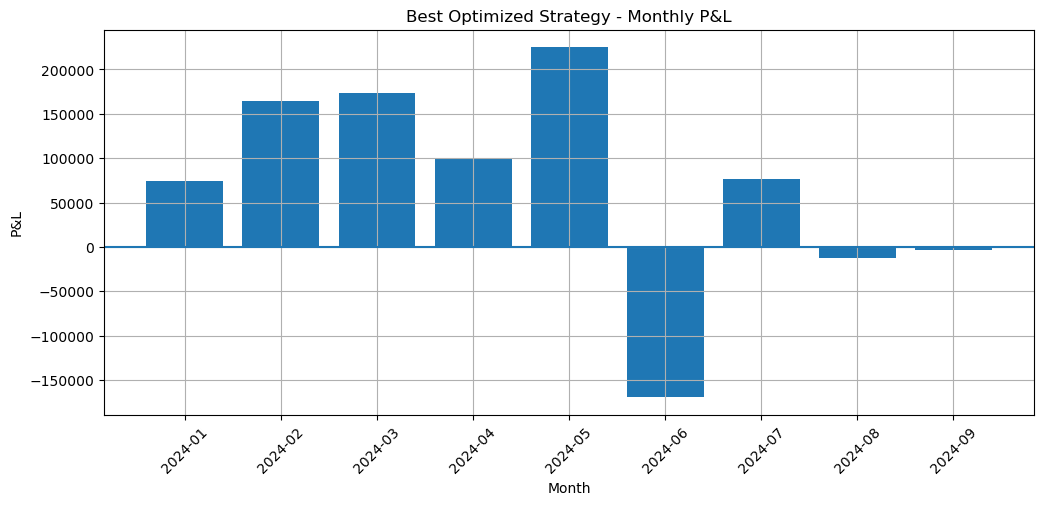

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.bar(best_monthly_pnl["month"], best_monthly_pnl["pnl"])
plt.xticks(rotation=45)
plt.axhline(0)
plt.title("Best Optimized Strategy - Monthly P&L")
plt.ylabel("P&L")
plt.xlabel("Month")
plt.grid(True)
plt.show()


In [123]:
#Cell 46 Best Setup Heat Map

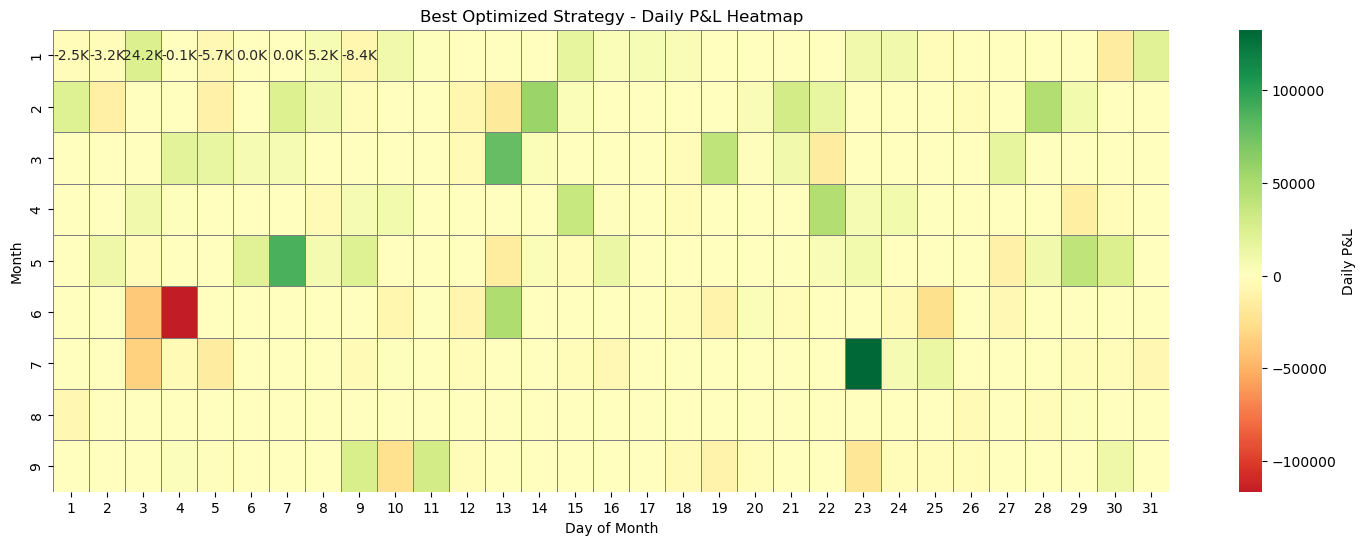

In [125]:
import seaborn as sns

best_daily_pnl["date"] = pd.to_datetime(best_daily_pnl["date"])
best_daily_pnl["month_num"] = best_daily_pnl["date"].dt.month
best_daily_pnl["day"] = best_daily_pnl["date"].dt.day

best_heatmap_df = best_daily_pnl.pivot(index="month_num", columns="day", values="pnl").fillna(0)
best_labels = best_heatmap_df.map(lambda x: f"{x/1000:.1f}K")

plt.figure(figsize=(18, 6))
sns.heatmap(
    best_heatmap_df,
    cmap="RdYlGn",
    center=0,
    annot=best_labels,
    fmt="",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Daily P&L"}
)
plt.title("Best Optimized Strategy - Daily P&L Heatmap")
plt.xlabel("Day of Month")
plt.ylabel("Month")
plt.show()


In [266]:
# CEll 47 Export

In [268]:
results_df.to_csv(
    "../Data/survivor_optimizer_results.csv",
    index=False
)

best_trades_df.to_csv(
    "../Data/survivor_best_trades.csv",
    index=False
)

best_daily_pnl.to_csv(
    "../Data/survivor_best_daily_pnl.csv",
    index=False
)

best_monthly_pnl.to_csv(
    "../Data/survivor_best_monthly_pnl.csv",
    index=False
)

print("Optimizer files exported")


Optimizer files exported
